In [2]:
!pip install streamlit pyngrok -q
!pip install -q langgraph langchain langchain-core langchain-groq python-dotenv

In [3]:
%%writefile langgraph_tool_backend.py
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
import os

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.environ.get("GROQ_API_KEY")
)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

checkpointer = InMemorySaver()
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)
chatbot = graph.compile(checkpointer=checkpointer)

Writing langgraph_tool_backend.py


In [4]:
%%writefile app.py
import streamlit as st
from langgraph_tool_backend import chatbot
from langchain_core.messages import HumanMessage, AIMessage
import uuid

def generate_thread_id():
    return str(uuid.uuid4())

def reset_chat():
    thread_id = generate_thread_id()
    st.session_state['thread_id'] = thread_id
    add_thread(st.session_state['thread_id'])
    st.session_state['message_history'] = []

def add_thread(thread_id):
    if thread_id not in st.session_state['chat_threads']:
        st.session_state['chat_threads'].append(thread_id)

def load_conversation(thread_id):
    state = chatbot.get_state(config={'configurable': {'thread_id': thread_id}})
    return state.values.get('messages', [])

if 'message_history' not in st.session_state:
    st.session_state['message_history'] = []

if 'thread_id' not in st.session_state:
    st.session_state['thread_id'] = generate_thread_id()

if 'chat_threads' not in st.session_state:
    st.session_state['chat_threads'] = []

add_thread(st.session_state['thread_id'])

st.sidebar.title('LangGraph Chatbot')

if st.sidebar.button('New Chat'):
    reset_chat()

st.sidebar.header('My Conversations')

for thread_id in st.session_state['chat_threads'][::-1]:
    if st.sidebar.button(str(thread_id)):
        st.session_state['thread_id'] = thread_id
        messages = load_conversation(thread_id)
        temp_messages = []
        for msg in messages:
            role = 'user' if isinstance(msg, HumanMessage) else 'assistant'
            temp_messages.append({'role': role, 'content': msg.content})
        st.session_state['message_history'] = temp_messages

for message in st.session_state['message_history']:
    with st.chat_message(message['role']):
        st.text(message['content'])

user_input = st.chat_input('Type here')

if user_input:
    st.session_state['message_history'].append({'role': 'user', 'content': user_input})
    with st.chat_message('user'):
        st.text(user_input)

    CONFIG = {'configurable': {'thread_id': st.session_state['thread_id']}}

    with st.chat_message("assistant"):
        def ai_only_stream():
            for message_chunk, metadata in chatbot.stream(
                {"messages": [HumanMessage(content=user_input)]},
                config=CONFIG,
                stream_mode="messages"
            ):
                if isinstance(message_chunk, AIMessage):
                    yield message_chunk.content

        ai_message = st.write_stream(ai_only_stream())

    st.session_state['message_history'].append({'role': 'assistant', 'content': ai_message})

Writing app.py


In [5]:
import os
os.environ["GROQ_API_KEY"] = ""

!streamlit run app.py &>/content/logs.txt &

from google.colab import userdata
from pyngrok import ngrok
import time

pyngrok_token = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(pyngrok_token)

time.sleep(3)
public_url = ngrok.connect(addr=8501)
print(public_url)

NgrokTunnel: "https://thrower-curvature-rigid.ngrok-free.dev" -> "http://localhost:8501"


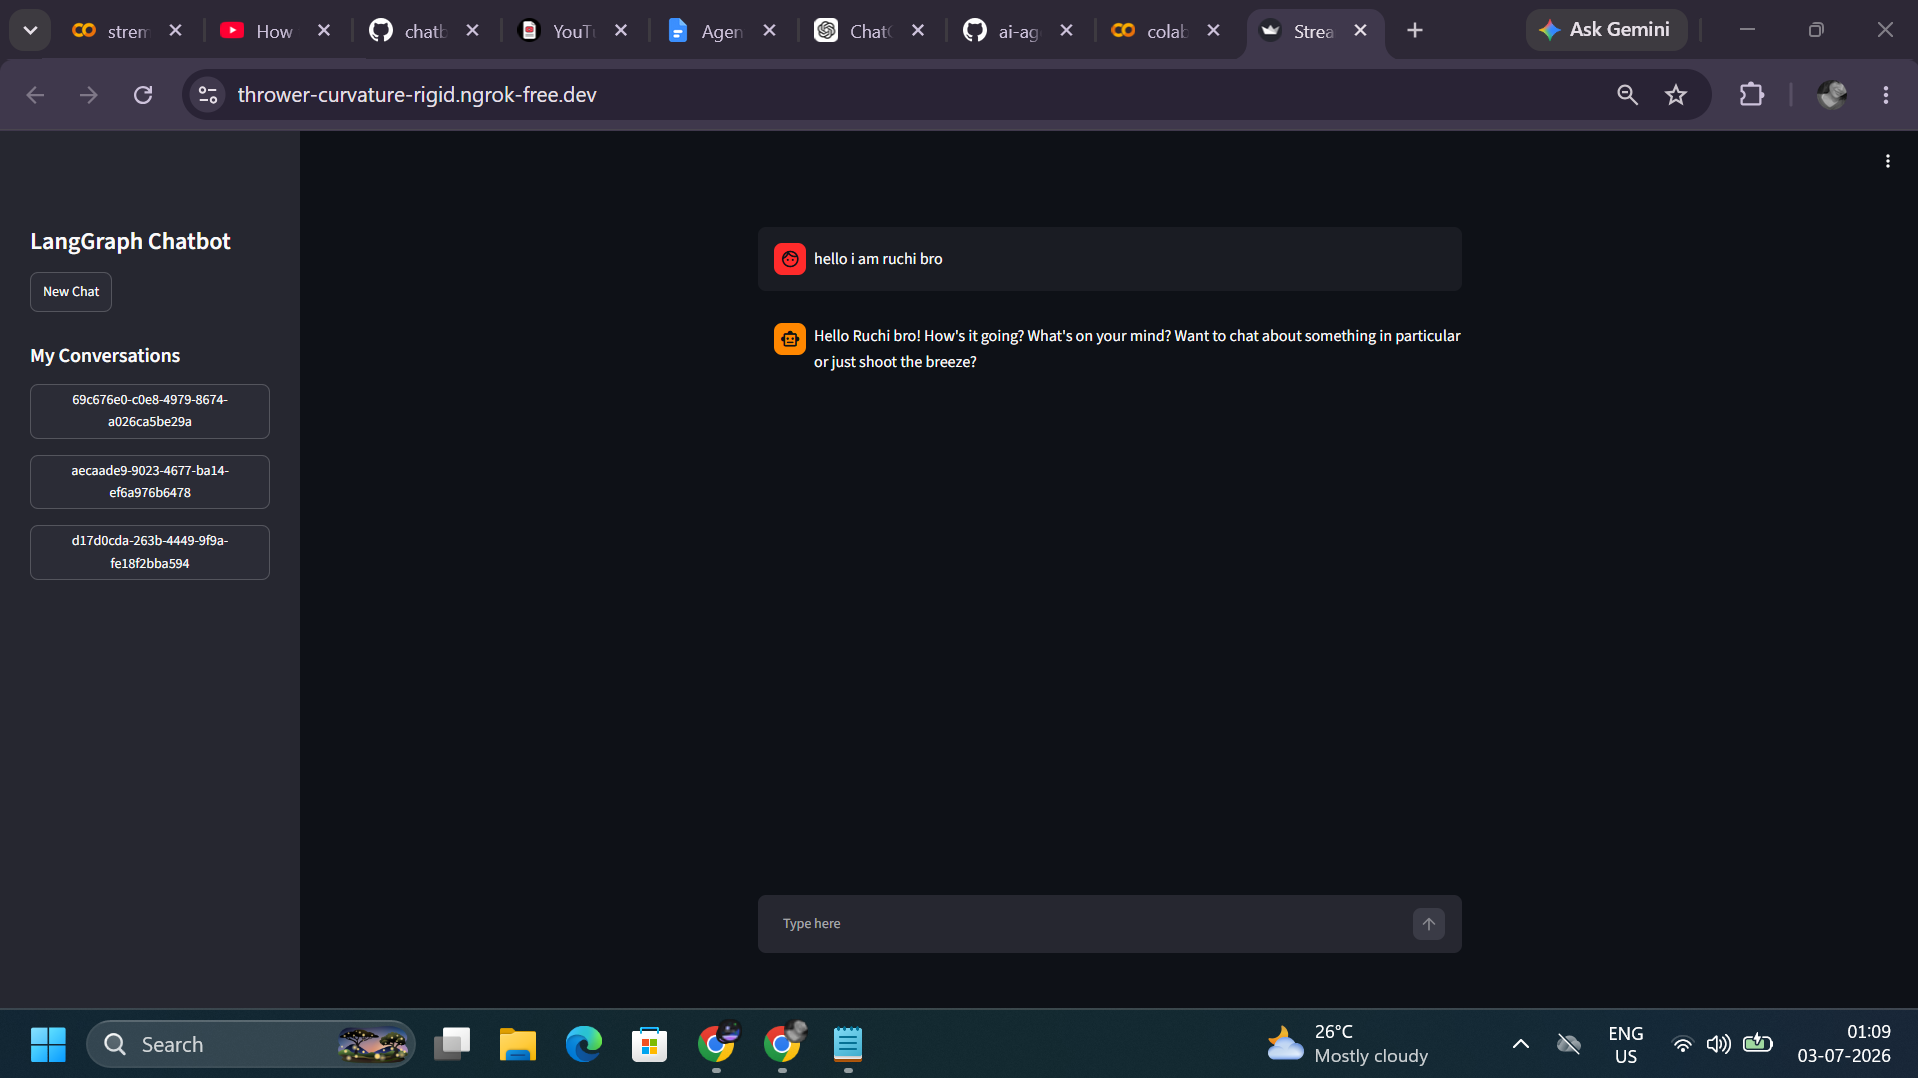

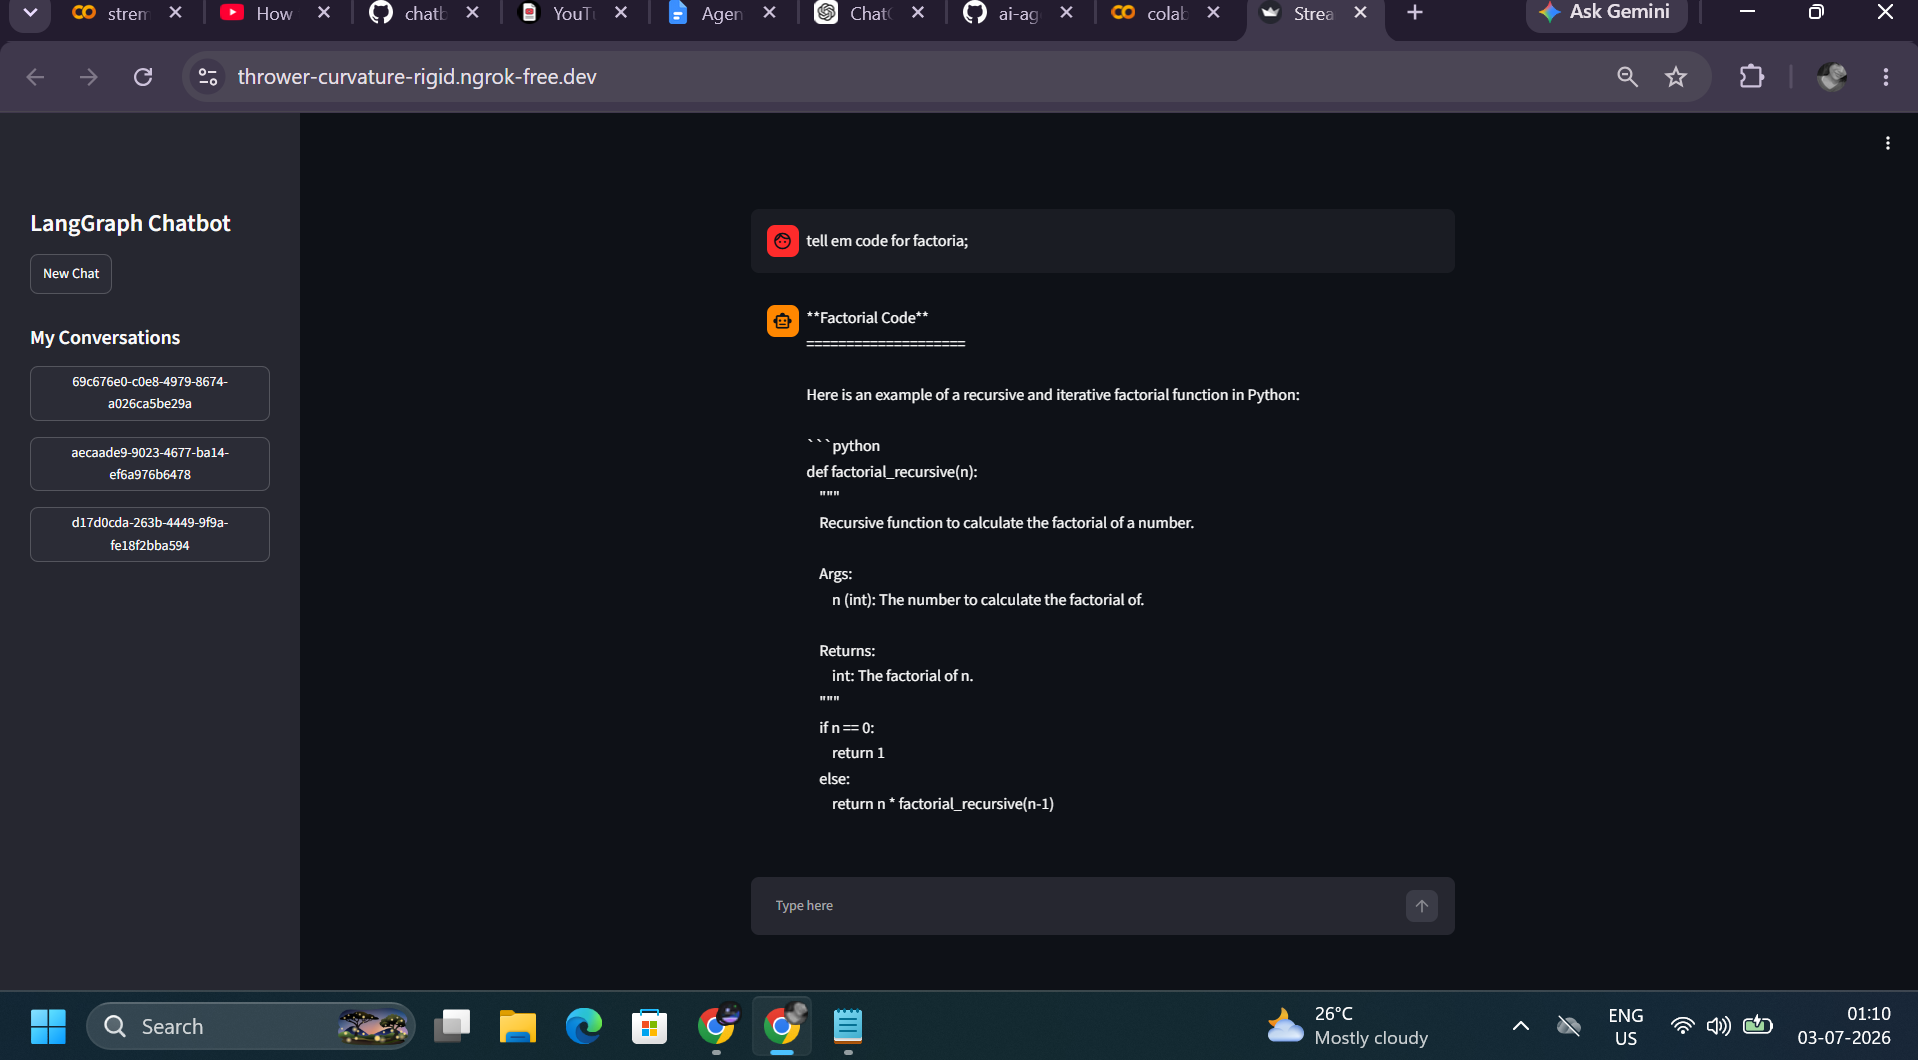

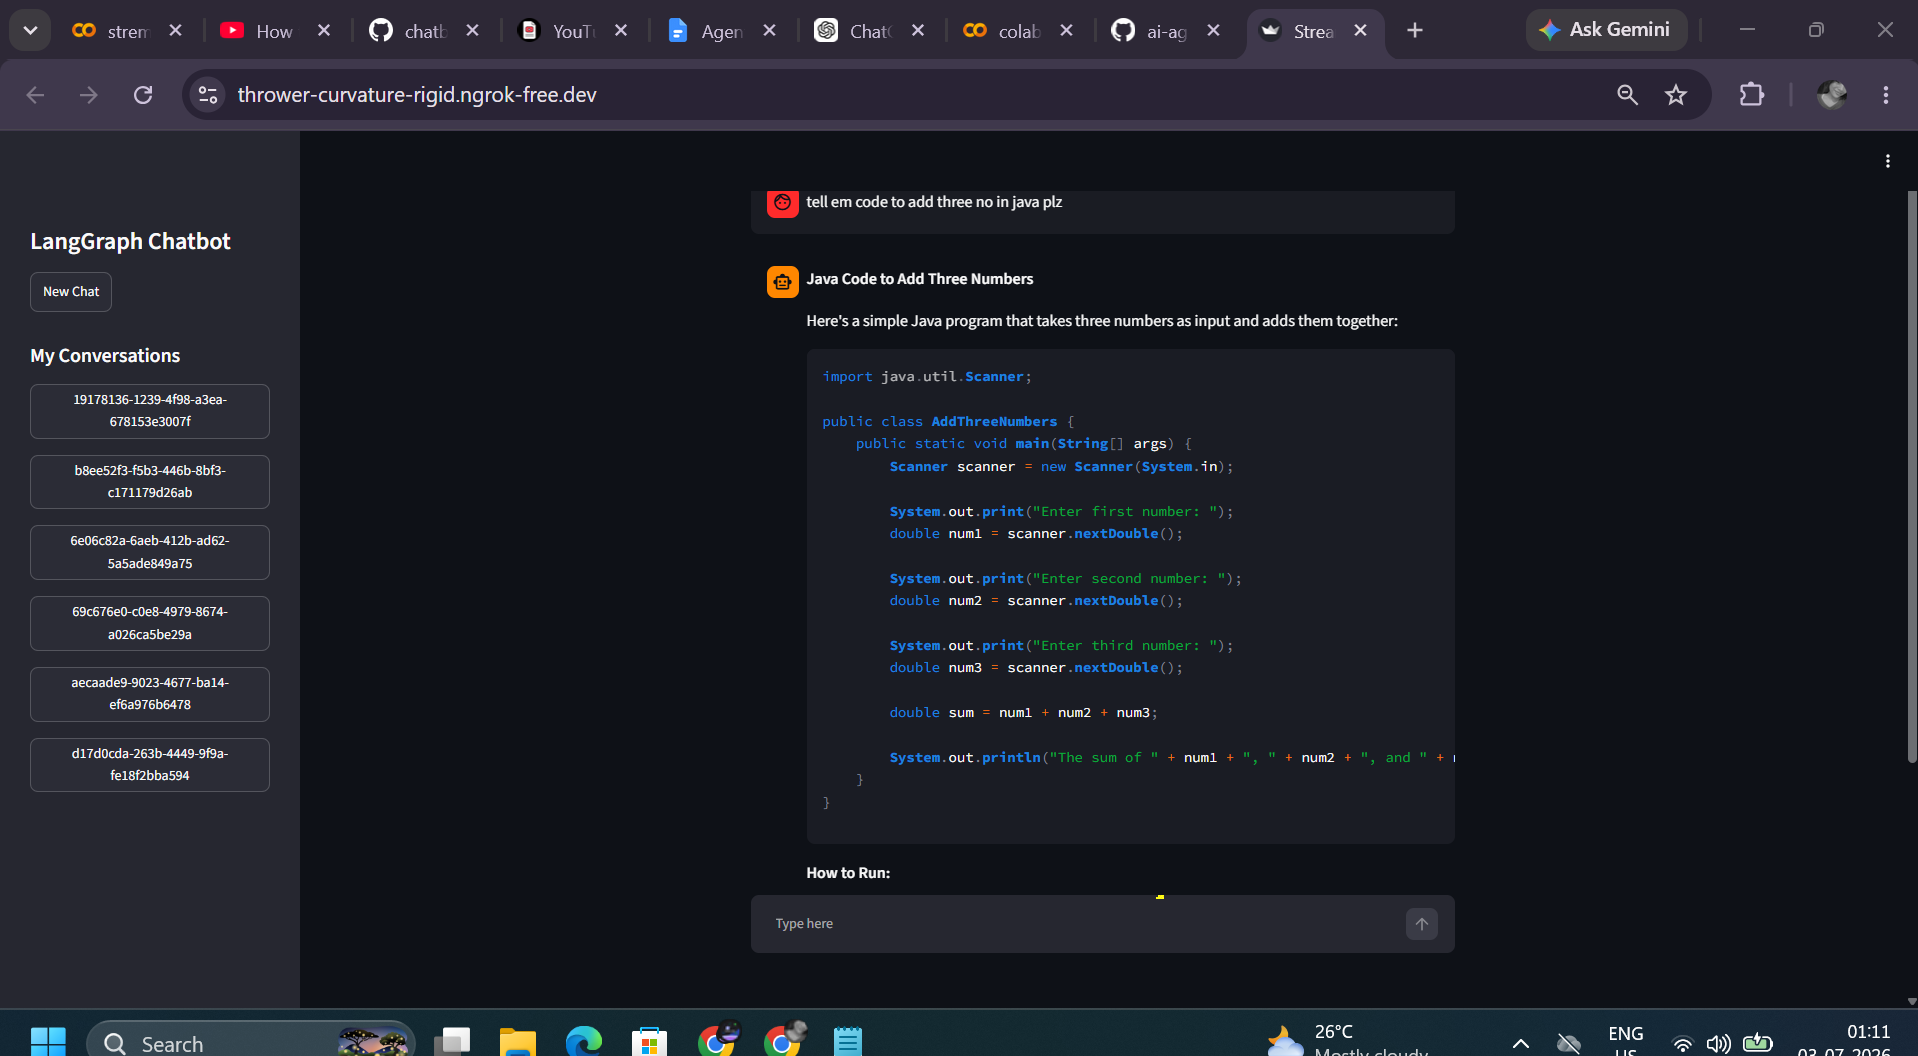